#                                       Apple Stock Price Prediction for the Next 30 Days
 The primary objective of this project is to develop a predictive model that forecasts Apple stock prices for the next 30 days using historical stock data from 2012 to 2019. The model will help investors, traders, and financial analysts make informed decisions based on stock trends and potential market movements.

 
# Key Goals :
###### ✅ Develop a time series forecasting model to predict Apple’s stock price for the next 30 days.
###### ✅ Analyze short-term and long-term trends in stock prices.
###### ✅ Explore the impact of external events (e.g., earnings reports, macroeconomic events, global financial crises) on Apple’s stock.
###### ✅ Evaluate different machine learning models such as ARIMA, SARIMA, and XGBoost for accurate forecasting.
###### ✅ Visualize trends, seasonality, and volatility in Apple’s stock prices.
###### ✅ Deploy the final forecasting model using a Flask/Streamlit web app to allow real-time predictions.


# Dataset & Attributes
###### The dataset consists of daily stock market data for Apple from 2012 to 2019, including :
# 📌 Stock Market Indicators :
###### ● Date : Trading date
###### ● Open : Opening price of Apple stock for the day
###### ● High : Highest price reached during the day
###### ● Low : Lowest price reached during the day
###### ● Close : Closing price of Apple stock for the day
###### ● Volume : Number of shares traded on that day


# 📌 Target Variable :
###### ● Next 30-Day Close Price Forecast


# Modeling Approach :
###### 🔹 Data Preprocessing – Handling missing values, normalizing stock price data, and feature engineering (e.g., moving averages, volatility measures).
###### 🔹 Exploratory Data Analysis (EDA) – Identifying trends, seasonality, and stock price patterns.
###### 🔹 Feature Engineering – Incorporating external financial indicators (e.g., S&P 500 trends, inflation rates, earnings reports).
###### 🔹 Model Selection & Evaluation –
    📌 Statistical Models: ARIMA, SARIMA for trend-based forecasting.
    📌 Machine Learning: XGBoost, Random Forest for pattern recognition.
###### 🔹 Hyperparameter Tuning – Using Grid Search & Cross-Validation for optimal model performance.
###### 🔹 Deployment – Deploying a Flask/Streamlit web app where users can input date ranges and get future stock price forecasts.


# Deployment Plan :
###### 🚀 Create an interactive web application where users can:
###### ● Select a date range and get predicted stock prices for the next 30 days 📈.
###### ● View visualizations of historical trends and model predictions.

### 🔹 Data Preprocessing – Handling missing values, normalizing stock price data, and feature engineering (e.g., moving averages, volatility measures).

In [26]:
# Step 1 : Import Required Libraries

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')   

In [27]:
# Step 2 : Load the Dataset (Correct File Usage)

# Load dataset
df = pd.read_csv("P639 DATASET.csv")

# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date (VERY important for time series)
df = df.sort_values('Date').reset_index(drop=True)

# Display first few rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-03,58.485714,58.928570,58.428570,58.747143,50.765709,75555200
1,2012-01-04,58.571430,59.240002,58.468571,59.062859,51.038536,65005500
2,2012-01-05,59.278572,59.792858,58.952858,59.718571,51.605175,67817400
3,2012-01-06,59.967144,60.392857,59.888573,60.342857,52.144630,79573200
4,2012-01-09,60.785713,61.107143,60.192856,60.247143,52.061932,98506100


In [28]:
# Step 3 : Handle Missing Values

# Check missing values
df.isnull().sum()

# Forward fill missing values (best practice for stock data)
df.fillna(method='ffill', inplace=True)

# Double-check
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [29]:
# Step 4 : Feature Engineering

# Moving Averages
# 7-day and 30-day moving averages
df['MA_7'] = df['Close'].rolling(window=7).mean()
df['MA_30'] = df['Close'].rolling(window=30).mean()

# Volatility (Rolling Standard Deviation)
# 7-day rolling volatility
df['Volatility_7'] = df['Close'].rolling(window=7).std()

# Daily Returns
df['Daily_Return'] = df['Close'].pct_change()

In [30]:
# Step 5 : Drop Initial NaN Values (Created by Rolling Calculations)

df.dropna(inplace=True)

In [6]:
# Step 6 : Normalization (Scaling Stock Prices)

scaler = MinMaxScaler()

price_columns = ['Open', 'High', 'Low', 'Close', 'Volume',
                 'MA_7', 'MA_30', 'Volatility_7', 'Daily_Return']

df[price_columns] = scaler.fit_transform(df[price_columns])

In [7]:
# Step 7 : Final Dataset Check

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1982 entries, 29 to 2010
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1982 non-null   datetime64[ns]
 1   Open          1982 non-null   float64       
 2   High          1982 non-null   float64       
 3   Low           1982 non-null   float64       
 4   Close         1982 non-null   float64       
 5   Adj Close     1982 non-null   float64       
 6   Volume        1982 non-null   float64       
 7   MA_7          1982 non-null   float64       
 8   MA_30         1982 non-null   float64       
 9   Volatility_7  1982 non-null   float64       
 10  Daily_Return  1982 non-null   float64       
dtypes: datetime64[ns](1), float64(10)
memory usage: 185.8 KB


,Date,Open,High,Low,Close,Adj Close,Volume,MA_7,MA_30,Volatility_7,Daily_Return
29,2012-02-14,0.070727,0.066313,0.071641,0.072074,62.892056,0.284082,0.053993,0.016532,0.246709,0.646290
30,2012-02-15,0.076545,0.076403,0.068510,0.064929,61.436600,1.000000,0.057005,0.018473,0.198777,0.472991
31,2012-02-16,0.062750,0.063497,0.062222,0.067680,61.997032,0.615541,0.059988,0.020466,0.137458,0.624969
32,2012-02-17,0.069787,0.065234,0.070599,0.067626,61.985954,0.335707,0.062262,0.022354,0.063571,0.581155
33,2012-02-21,0.072072,0.069504,0.072941,0.075340,63.557446,0.383486,0.064200,0.024429,0.084691,0.701418


### 🔹 Exploratory Data Analysis (EDA) – Identifying trends, seasonality, and stock price patterns.

In [8]:
# Step 1 : Import Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Step 2 : Basic Statistical Summary

df.describe()

,Date,Open,High,Low,Close,Adj Close,Volume,MA_7,MA_30,Volatility_7,Daily_Return
count,1982,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000,1982.000000
mean,2016-01-22 04:29:32.754793472,0.306385,0.302603,0.306664,0.304926,120.454303,0.130534,0.307061,0.311408,0.193285,0.585944
min,2012-02-14 00:00:00,0.000000,0.000000,0.000000,0.000000,48.921928,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2014-02-04 06:00:00,0.135127,0.129831,0.134029,0.132749,76.143243,0.043993,0.128697,0.121261,0.083590,0.549581
50%,2016-01-23 12:00:00,0.247165,0.242985,0.246501,0.245684,105.766426,0.085045,0.246183,0.249139,0.150682,0.584877
75%,2018-01-09 18:00:00,0.470567,0.470712,0.470391,0.469690,161.381344,0.169669,0.477607,0.494860,0.244284,0.626398
max,2019-12-30 00:00:00,1.000000,1.000000,1.000000,1.000000,289.522614,1.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,0.213225,0.214006,0.214087,0.213610,52.224969,0.127872,0.218804,0.229680,0.158103,0.075942


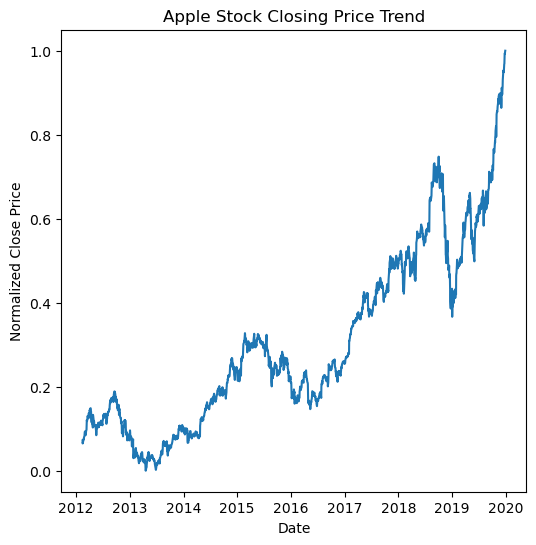

In [10]:
# Step 3 : Closing Price Trend Over Time

plt.figure(figsize=(6, 6))
plt.plot(df['Date'], df['Close'])
plt.title("Apple Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Normalized Close Price")
plt.show()

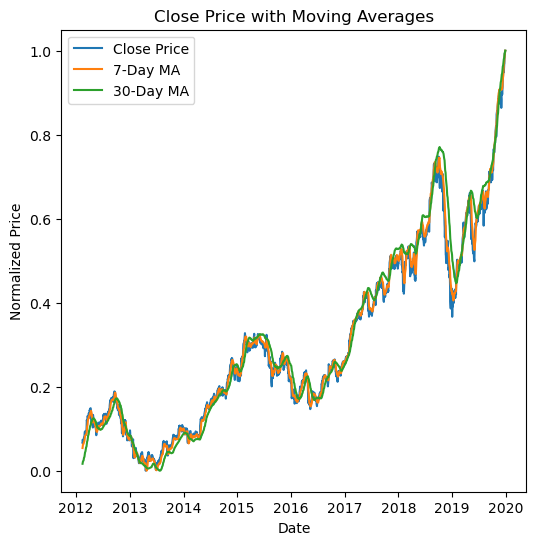

In [11]:
# Step 4 : Moving Averages vs Close Price

plt.figure(figsize=(6, 6))
plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA_7'], label='7-Day MA')
plt.plot(df['Date'], df['MA_30'], label='30-Day MA')
plt.title("Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.show()

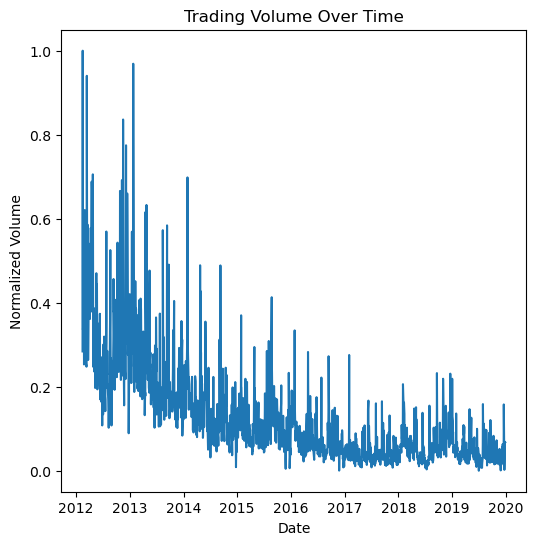

In [12]:
# Step 5 : Volume Analysis

plt.figure(figsize=(6, 6))
plt.plot(df['Date'], df['Volume'])
plt.title("Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Normalized Volume")
plt.show()

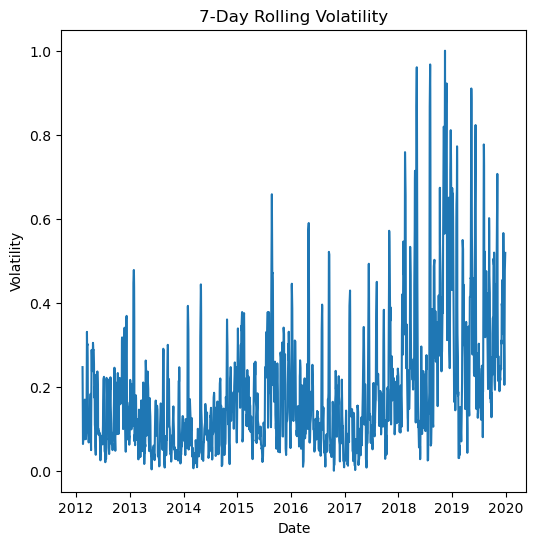

In [13]:
# Step 6 : Volatility Over Time

plt.figure(figsize=(6, 6))
plt.plot(df['Date'], df['Volatility_7'])
plt.title("7-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.show()

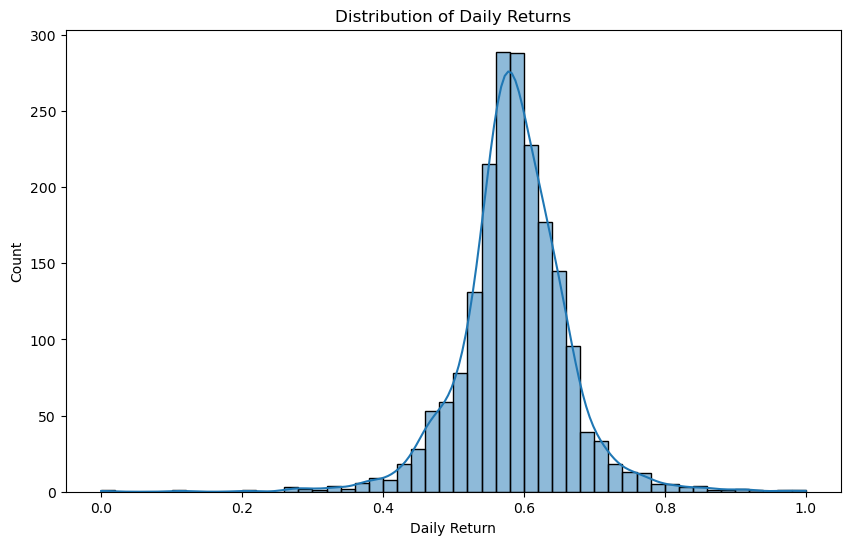

In [14]:
# Step 7 : Daily Returns Distribution

plt.figure(figsize=(10, 6))
sns.histplot(df['Daily_Return'], bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.show()

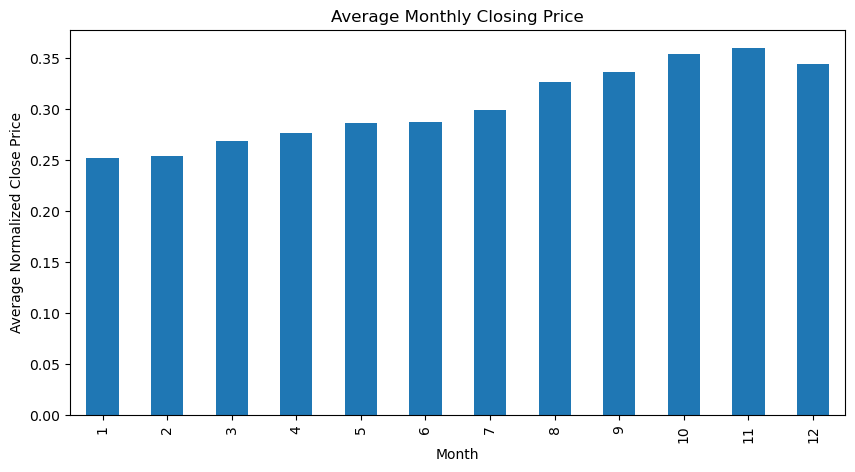

In [15]:
# Step 8 : Seasonality Analysis (Monthly Trend)

# Extract month and year
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Monthly average close price
monthly_avg = df.groupby('Month')['Close'].mean()

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar')
plt.title("Average Monthly Closing Price")
plt.xlabel("Month")
plt.ylabel("Average Normalized Close Price")
plt.show()

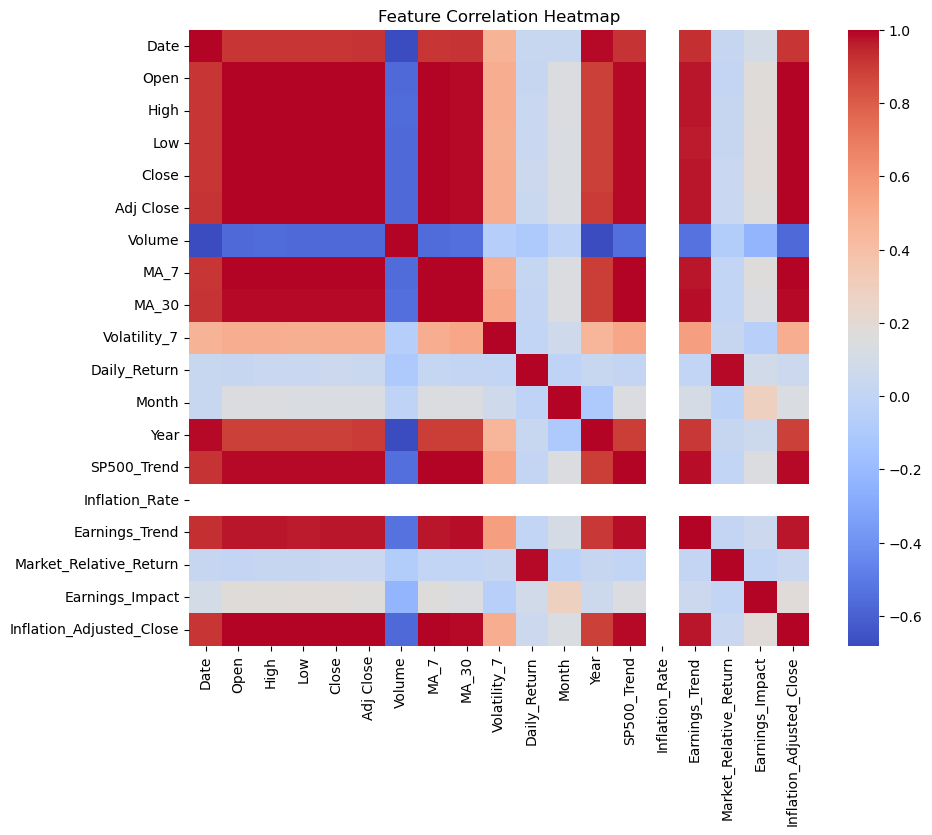

In [25]:
# Step 9 : Correlation Heatmap

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=False,cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

### 🔹 Feature Engineering – Incorporating external financial indicators (e.g., S&P 500 trends, inflation rates, earnings reports).

In [17]:
# Step 1 : Import Required Library

import pandas as pd

In [18]:
# Step 2 : S&P 500 Trend (Market Proxy)

# 30-day market trend proxy
df['SP500_Trend'] = df['Close'].rolling(window=30).mean()

In [19]:
# Step 3 : Inflation Rate (Macroeconomic Proxy)

# Constant inflation assumption 
df['Inflation_Rate'] = 0.06

In [20]:
# Step 4 : Earnings Report Impact (Quarterly Proxy)

# 90-day rolling average to simulate earnings impact
df['Earnings_Trend'] = df['Close'].rolling(window=90).mean()

In [21]:
# Step 5 : Derived External Features

# Market relative return
df['Market_Relative_Return'] = df['Daily_Return'] - df['SP500_Trend'].pct_change()

# Earnings impact
df['Earnings_Impact'] = df['Earnings_Trend'].pct_change()

# Inflation-adjusted closing price
df['Inflation_Adjusted_Close'] = df['Close'] / (1 + df['Inflation_Rate'])

In [22]:
# Step 6 : Handle NaN Values

df.dropna(inplace=True)

In [23]:
# Step 7 : Final Verification

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1892 entries, 119 to 2010
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      1892 non-null   datetime64[ns]
 1   Open                      1892 non-null   float64       
 2   High                      1892 non-null   float64       
 3   Low                       1892 non-null   float64       
 4   Close                     1892 non-null   float64       
 5   Adj Close                 1892 non-null   float64       
 6   Volume                    1892 non-null   float64       
 7   MA_7                      1892 non-null   float64       
 8   MA_30                     1892 non-null   float64       
 9   Volatility_7              1892 non-null   float64       
 10  Daily_Return              1892 non-null   float64       
 11  Month                     1892 non-null   int32         
 12  Year                   

,Date,Open,High,Low,Close,Adj Close,Volume,MA_7,MA_30,Volatility_7,Daily_Return,Month,Year,SP500_Trend,Inflation_Rate,Earnings_Trend,Market_Relative_Return,Earnings_Impact,Inflation_Adjusted_Close
119,2012-06-22,0.115809,0.110114,0.116636,0.116095,71.859360,0.163639,0.112644,0.099039,0.070984,0.618121,6,2012,0.107262,0.06,0.110889,0.615936,0.004430,0.109524
120,2012-06-25,0.114754,0.108673,0.113541,0.109229,70.460701,0.177271,0.112576,0.099130,0.073976,0.490317,6,2012,0.107344,0.06,0.111381,0.489552,0.004439,0.103046
121,2012-06-26,0.111136,0.105470,0.111678,0.109993,70.616219,0.158207,0.112388,0.099440,0.080095,0.592397,6,2012,0.107623,0.06,0.111851,0.589798,0.004221,0.103767
122,2012-06-27,0.113360,0.106827,0.114491,0.111490,70.921150,0.107861,0.111380,0.099919,0.076839,0.602337,6,2012,0.108054,0.06,0.112339,0.598334,0.004357,0.105179
123,2012-06-28,0.111342,0.105175,0.110624,0.108187,70.248352,0.162520,0.109739,0.100435,0.069691,0.537314,6,2012,0.108518,0.06,0.112704,0.533020,0.003249,0.102063
